# Practice 5.
##  Objectives:
1. Understand the projection methods for classification.
2. Understand the Fisher discriminant.

2. Do a simple exploratory data analysis
3. Learn the **data cleaning and visualitzation** features of Pandas.
## Aplication:
Data basse: Data set from the UCI Machine Learning Repository
(http://archive.ics.uci.edu/ml)

 Database: Wine quality, http://archive.ics.uci.edu/ml/datasets/Wine+Quality
- Predict **quality** (score between 0 and 10)

In [2]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
# Changed from sklearn.metrics import plot_confusion_matrix, devaluated in sklearn 1.1.0, replaced with ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
File = "winequality-red.csv"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')
Data = pd.read_csv(Filename)
Data.head().T


Filename with path: 
 c:\Users\Marcel\Uni\Master\MLEARN\MLEARN\Practicas\FifthPractice\Data\winequality-red.csv


,0,1,2,3,4
fixed acidity,7.4000,7.8000,7.800,11.200,7.4000
volatile acidity,0.7000,0.8800,0.760,0.280,0.7000
citric acid,0.0000,0.0000,0.040,0.560,0.0000
residual sugar,1.9000,2.6000,2.300,1.900,1.9000
chlorides,0.0760,0.0980,0.092,0.075,0.0760
free sulfur dioxide,11.0000,25.0000,15.000,17.000,11.0000
total sulfur dioxide,34.0000,67.0000,54.000,60.000,34.0000
density,0.9978,0.9968,0.997,0.998,0.9978
pH,3.5100,3.2000,3.260,3.160,3.5100
sulphates,0.5600,0.6800,0.650,0.580,0.5600


In [6]:
Data.dtypes
print(f'Shape of the database:{Data.shape}')

Shape of the database:(1599, 12)


In [7]:
Data.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.32,1.74,4.60,7.10,7.90,9.20,15.90
volatile acidity,1599.0,0.53,0.18,0.12,0.39,0.52,0.64,1.58
citric acid,1599.0,0.27,0.19,0.00,0.09,0.26,0.42,1.00
residual sugar,1599.0,2.54,1.41,0.90,1.90,2.20,2.60,15.50
chlorides,1599.0,0.09,0.05,0.01,0.07,0.08,0.09,0.61
free sulfur dioxide,1599.0,15.87,10.46,1.00,7.00,14.00,21.00,72.00
total sulfur dioxide,1599.0,46.47,32.90,6.00,22.00,38.00,62.00,289.00
density,1599.0,1.00,0.00,0.99,1.00,1.00,1.00,1.00
pH,1599.0,3.31,0.15,2.74,3.21,3.31,3.40,4.01
sulphates,1599.0,0.66,0.17,0.33,0.55,0.62,0.73,2.00


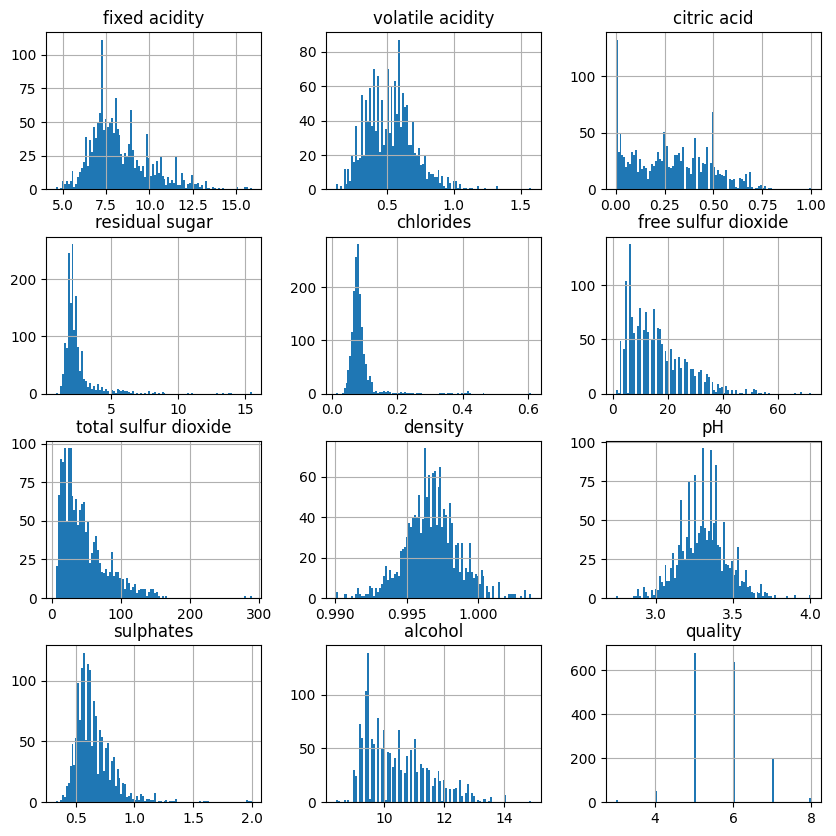

In [8]:
ax =Data.hist(figsize= (10,10),bins = 100)

Note: predicted qualities are **unbalanced** 


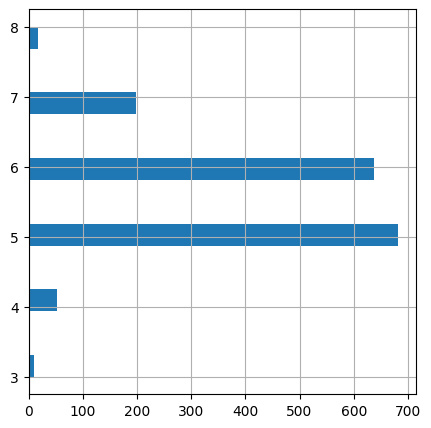

In [9]:
ax =Data['quality'].hist(figsize= (5,5),orientation="horizontal",bins = 16)
print('Note: predicted qualities are **unbalanced** ')

## Lets reduce the number of classes to three: low, medium, high

In [10]:

CodingQuality ={3:1,4:1,5:1,6:2,7:3,8:3}
Data['quality'] = Data['quality'].map(CodingQuality)

Note: predicted qualities are almost balanced 


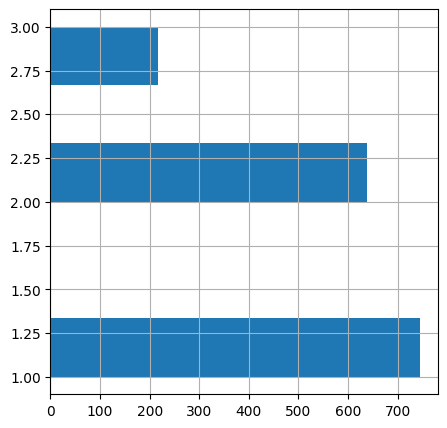

In [11]:
ax =Data['quality'].hist(figsize= (5,5),orientation="horizontal",bins = 6)
print('Note: predicted qualities are almost balanced ')

### Scatter plot.
**Note that the class quality is coded with a color, i.e. c =Data['quality']**

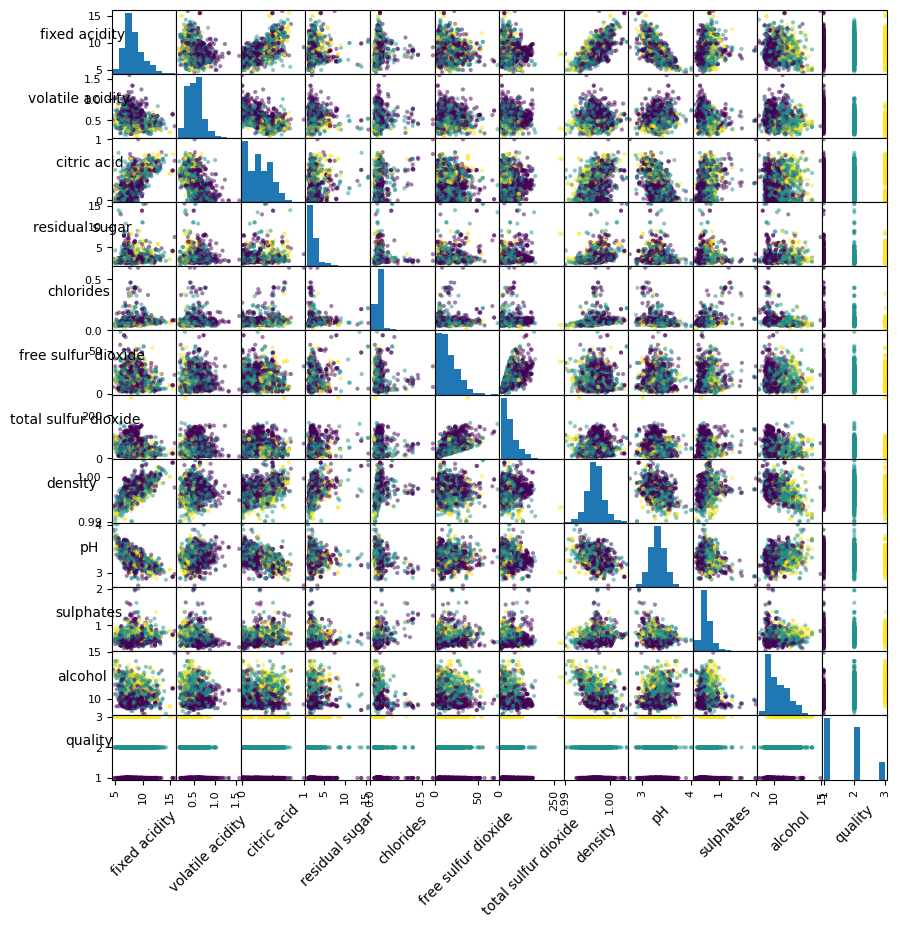

In [ ]:
if False:
    ax = pd.plotting.scatter_matrix(Data,c =Data['quality'], figsize = (10,10))
    for a in ax.ravel():
        a.set_xlabel(a.get_xlabel(), rotation=45)
        a.set_ylabel(a.get_ylabel(), rotation=0)

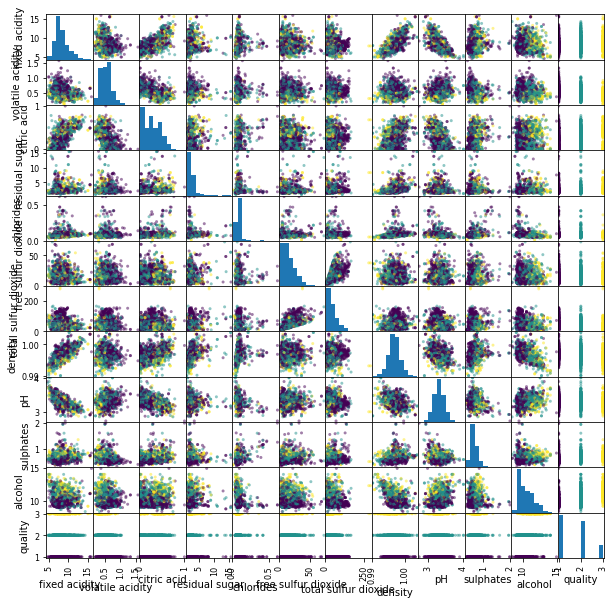

## Partition database into train and test

Note the helper function

In [14]:
def PartitionOfDatabase(Data,Fraction = 0.75):
    NumSamples, NumFeatures = Data.shape
    Index = list(range(NumSamples))
    RandomIndex = np.random.permutation(Index)
    NumTrainElements = int(Fraction*NumSamples)
    TrainIndex = RandomIndex[:NumTrainElements]
    TestIndex = RandomIndex[NumTrainElements:]
    TrainDB = Data.iloc[TrainIndex]
    TestDB = Data.iloc[TestIndex]
    return TrainDB,TestDB
TrainDB,TestDB = PartitionOfDatabase(Data,Fraction = 0.75)

In [15]:
y = TrainDB['quality']
InputFeatures = [fea for fea in TrainDB.columns if  fea != 'quality']
print(f' Input variables: \n {InputFeatures}')
print('_'*50)
X = TrainDB[InputFeatures]

 Input variables: 
 ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
__________________________________________________


## Next we standarize the data, so that it has mean zero and standard deviation equal to one.

##  $z = {(x - mean) \over  std}$
### Important: Use the same scaler for the test database

In [17]:
scaler = StandardScaler()
print(scaler.fit(X))
X =scaler.transform(X)
X = pd.DataFrame(data = X, columns = InputFeatures)
X.describe().round(2).T
# print('** Important: Use the same scaler for the test database!**')

StandardScaler()


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1199.0,0.0,1.0,-2.14,-0.69,-0.23,0.52,4.40
volatile acidity,1199.0,0.0,1.0,-2.27,-0.76,-0.02,0.62,5.94
citric acid,1199.0,0.0,1.0,-1.41,-0.89,-0.06,0.82,2.68
residual sugar,1199.0,-0.0,1.0,-1.14,-0.45,-0.24,0.03,8.93
chlorides,1199.0,0.0,1.0,-1.70,-0.37,-0.16,0.09,12.06
free sulfur dioxide,1199.0,0.0,1.0,-1.44,-0.86,-0.19,0.52,5.34
total sulfur dioxide,1199.0,0.0,1.0,-1.23,-0.75,-0.27,0.47,7.20
density,1199.0,0.0,1.0,-3.51,-0.60,-0.01,0.58,3.68
pH,1199.0,0.0,1.0,-2.85,-0.66,-0.02,0.56,4.50
sulphates,1199.0,0.0,1.0,-1.95,-0.64,-0.23,0.43,7.86


## We create the projection into 2D by the two methods.

In [18]:
Dimension_of_projection = 2

In [19]:
lda = LinearDiscriminantAnalysis(n_components=Dimension_of_projection)
X_lda = lda.fit(X, y).transform(X)

X_lda = pd.DataFrame(data = X_lda, columns = ['dim1','dim2'])

## Homework: <font color='red'> State briefly the criterion for deriving each method and the underlying hypothesis.</font>

### Homework: <font color='red'>  Given a multidimensional Gaussian with $x \in \mathbb{R}^p$, which is the distribution of a linear combination of the dimensions of $x$ ?</font>

## Homework: <font color='green'> State briefly the criterion for deriving each method and the underlying hypothesis.</font>
---
En el caso de la regresión lineal, el criterio que utilizamos es minimizar el RSS (Residual Sum of Squares), es decir, minimizar el error cuadrático entre las predicciones y los valores reales en función de las betas. Para ello derivamos la función de error respecto a las betas e igualamos a cero para encontrar el mínimo. Este mínimo es único debido a que la función es convexa. La hipótesis subyacente es que existe una relación lineal entre las variables de entrada y la variable de salida.

En la regresión logística también derivamos, pero en este caso el criterio es maximizar la verosimilitud (likelihood) de los datos. Para facilitar los cálculos se utiliza el logaritmo, obteniendo la log-verosimilitud, que es la función que realmente se optimiza. Esto nos permite encontrar los parámetros que mejor separan las clases en términos probabilísticos. La hipótesis subyacente es que el logaritmo de la razón de probabilidades (log-odds) es una función lineal de las variables de entrada.

---
## Homework: <font color='green'>  Given a multidimensional Gaussian with $x \in \mathbb{R}^p$, which is the distribution of a linear combination of the dimensions of $x$ ?</font>
---
La distribución seguirá siendo Gaussiana. Esto se debe a que la Multivariate Normal Distribution es cerrada bajo combinaciones lineales, es decir, si aplicamos una combinación lineal de sus variables, el resultado sigue siendo una distribución normal.

En este caso, al tomar una combinación lineal de las dimensiones de x, obtenemos una variable aleatoria unidimensional que sigue una distribución Gaussiana. Lo que cambia son sus parámetros (media y varianza), pero no el tipo de distribución.

---

## Description of the projected elements

In [22]:
X_lda.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
dim1,1199.0,0.0,1.27,-2.79,-1.02,-0.14,0.95,5.16
dim2,1199.0,0.0,1.01,-2.74,-0.70,-0.10,0.59,7.68


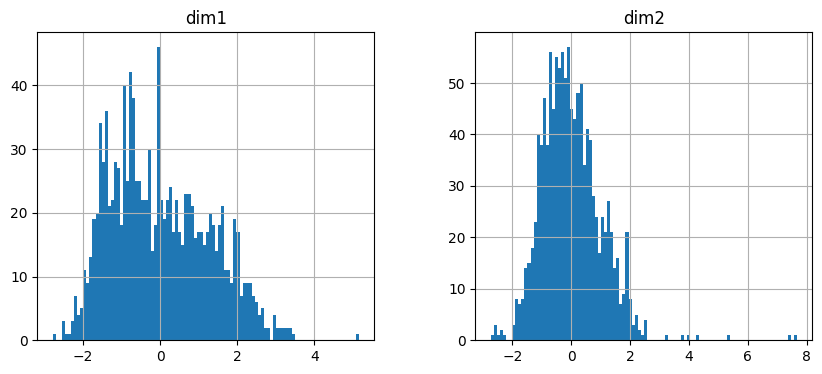

In [21]:
ax = X_lda.hist(figsize = (10,4),bins = 100)


## Homework: <font color='red'> Give a summary by words of the statistical distributions.</font>
1. Is the mean different from the percentile 50%. 
2. Is the std  deviation comparable to the interquantile distance (i.e. difference between the percentile 75% and the percentile 25%)
3. How many stds are the minimum and maximum from the mean value. Is it likely for a Gaussian?
4. <font color='red'> Do the hypothesis of the methods stand?.</font>  

## Homework: <font color='green'> Give a summary by words of the statistical distributions.</font>

---
La media y el percentil 50% son diferentes, pero muy ligeramente.
- dim1: Media = 0.00, Mediana = -0.14 → Diferencia de 0.14
- dim2: Media = 0.00, Mediana = -0.10 → Diferencia de 0.10

En una distribución perfectamente Gaussiana, la media y la mediana deberían ser exactamente iguales.

---
---
A diferencia de el caso anterior, la desviación estandar para uno caso es similar a la interquantile distance, pero para el otro no.
- dim1: std = 1.27 → Valor esperado: 1.27 × 1.35 = 1.71; En este caso: 0.95-(-1.02) = 1.97
- dim2: std = 1.01 → Valor esperado: 1.01 × 1.35 = 1.36; En este caso: 0.59-(-0.70) = 1.29

El dim2 se comporta muy bien respecto a esto. El dim1 muestra un IQR más grande de lo esperado, cosa que podiamos esperar al ver el histograma con valores más altos no tan centrados alrededor de la media.

---
---
Calculamos cuantas desviaciones estandar están el mínimo y el máximo respecto la media:
- dim1: max: 5.16/1.27 = 4.06σ, min: -2.79/1.27 = -2.20σ
- dim2: max: 7.68/1.01 = 7.60σ, min: -2.74/1.01 = -2.71σ

Para que sea una distribución Gaussiana deberian encontrarse el mínimo y el máximo dentro de ±3σ, en este caso podemos ver como los mínimos de ambas dimensiones cumplen con la restricción pero los máximos no. En ambos casos podemos ver que hay outliers con valores muy superiores a la media, y sobre todo en el caso de la dim2, estos valores no podrían ser explicados por una Gaussiana. 

---
Las hipotesis de LDA no se cumplen completamente, solo parcialemnte, debido a que estas requieren:
- Distribución Gaussiana en cada clase → PARCIALMENTE (media ≠ mediana, sí hay asimetría)
- Datos con comportamiento Gaussiano similar → NO (especialmente con esos valores extremos a 7.6σ)
- Covarianzas iguales por clase → No estudiada, debido a que ya no cumplía la hipotesis
El LDA funciona razonablemente bien, pero no de forma perfecta, debido a que no cumple la hipotesis. Los datos no son perfectos y por esto encontramos outliers y una ligera asimetría.

---

## Lets look into the space of the projection

$P(.):x \in \mathbb{R}^{11} \longrightarrow   \mathbb{R}^2$ 

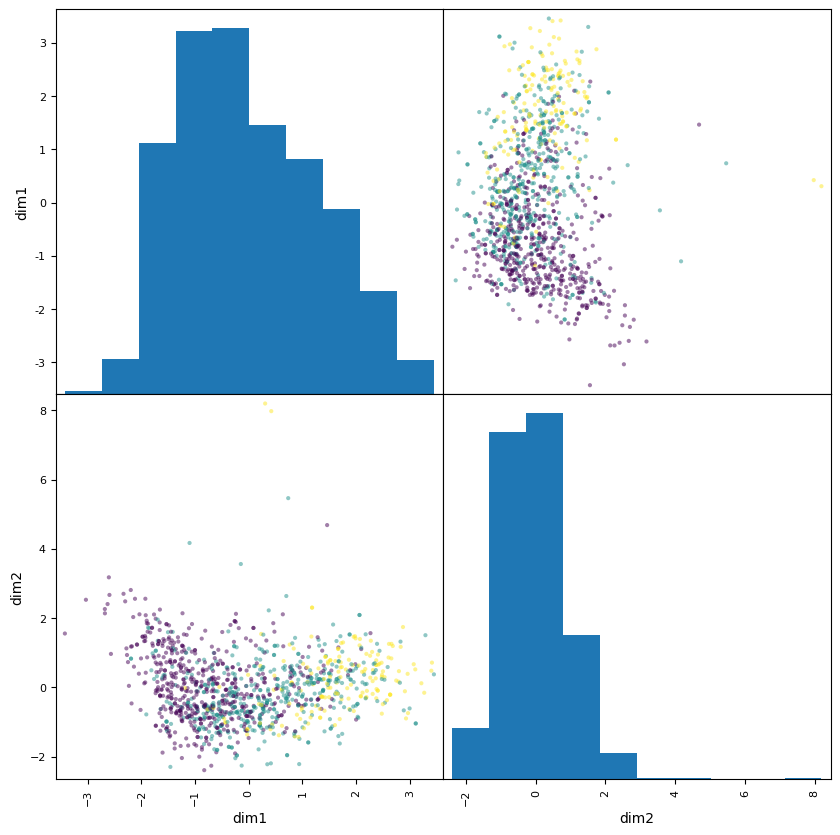

In [17]:
ax = pd.plotting.scatter_matrix(X_lda,c =y, figsize = (10,10))

In [23]:
lda.coef_[:1,:].shape


(1, 11)

In [24]:
Coef_Lda = pd.DataFrame(data = lda.coef_[:2,:].T, columns = ['Proj class 1','Proj class 2'],index =X.columns.values)
Coef_Lda

,Proj class 1,Proj class 2
fixed acidity,-0.223587,0.010406
volatile acidity,0.359296,-0.202348
citric acid,0.097505,-0.153384
residual sugar,-0.106978,-0.026656
chlorides,0.104100,-0.036290
free sulfur dioxide,-0.076319,0.097844
total sulfur dioxide,0.324392,-0.234841
density,0.117640,0.106445
pH,0.007918,-0.024153
sulphates,-0.290659,0.134265


Check what would have happened if we had not standarized.


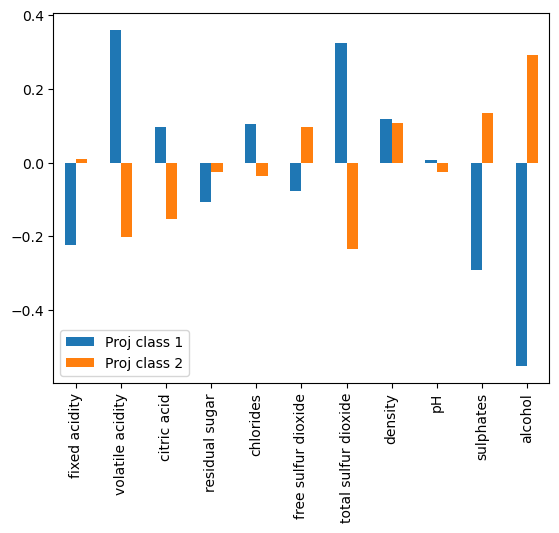

In [25]:
ax =Coef_Lda.plot.bar()
print('Check what would have happened if we had not standarized.')

In [28]:
print('Lets see how the means of each class compare to each other')
Means_Lda = pd.DataFrame(data = lda.means_.T, columns = ['Proj 1','Proj 2','Proj 3'],index =X.columns.values)
Means_Lda


Lets see how the means of each class compare to each other


,Proj 1,Proj 2,Proj 3
fixed acidity,-0.112883,0.010628,0.349401
volatile acidity,0.360536,-0.143846,-0.792943
citric acid,-0.180051,-0.005925,0.624536
residual sugar,-0.000651,-0.045591,0.136189
chlorides,0.114658,-0.054795,-0.225579
free sulfur dioxide,0.109157,-0.048198,-0.226419
total sulfur dioxide,0.277892,-0.184697,-0.394209
density,0.163879,-0.064836,-0.362037
pH,0.006446,0.056121,-0.186675
sulphates,-0.240193,0.111426,0.482433


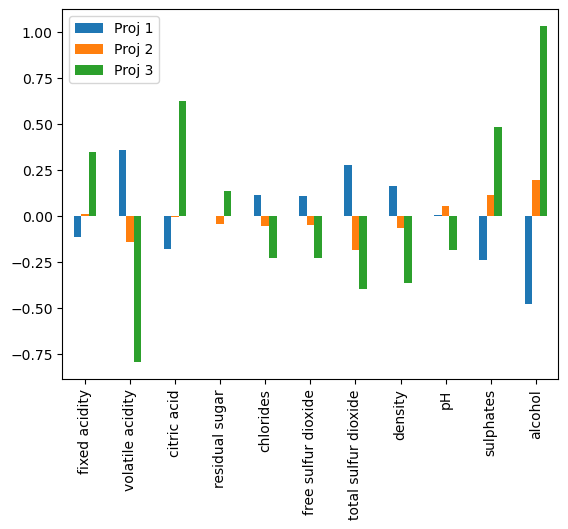

In [29]:
ax =Means_Lda.plot.bar()

## Homework: 

1. <font color='red'> Comment on the meaning of the coefficients. What is the result of having different signs and sizes of the values?</font>
2. <font color='red'> If you have time, what would have happened if we had not standarized? What is the influence of the size/order of magnitude of the features?</font>
3. <font color='red'> What can you say about the means in the sense of separation between classes? Note that there seems to be like a continuity between the centers of mass for each quality.</font>

## Homework: 

1. <font color='red'>  Create three logistic linear classifiers: Class 1 vs. {Class 2 and class 3}, Class 2 vs. {Class 1 and class 3}, Class 3 vs. {Class 1 and class 2}</font>
**Is there a difference between the performance on train and test?**

2. <font color='red'>  Do the classification on the original data, and on the data after the **lda** projection</font>
3. <font color='red'>   From the coefficients of the lda and  logistic linear classifiers, and the understanding of the problem, can you think of a feature engineering that might improve the problem</font>
4. **Remember: the 'l2' option in the logistic classifier does a regularization function.**

## Description of variables: Wine  quality
### Input variables (based on physicochemical tests):
1. fixed acidity
2. volatile acidity
3. citric acid
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol
Output variable (based on sensory data): 
12. quality (score between 0 and 10)
